In [6]:
import gc
import math
import random
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

Device : cpu


In [8]:
df = pd.read_csv(
    "/kaggle/input/datasets/rajatkhalkar/english-hindi-tranlations/English-Hindi-translated_words.csv"
)

print(df.head())

print()

print(df.shape)

                                             English  \
0  What would they have lost, had they believed i...   
1                                     Formatted name   
2  When it is said to them, "What is it that your...   
3  Gradually, through meetings with them, Daar ji...   
4  He is empowered to correct patent errors in a ...   

                                               Hindi  
0  अगर ये लोग ख़ुदा और रोज़े आख़िरत पर ईमान लाते ...  
1                                      फार्मेटेड नाम  
2  और जब उनसे कहा जाता है कि तुम्हारे परवरदिगार न...  
3  धीरे-धीरे इनके साथ बातचीत में दार जी और कई लोग...  
4  वह कोई विधेयक सदन द्वारा पास कर दिए जाने के पश...  

(1336876, 2)


In [9]:
df = df.dropna()

df = df.drop_duplicates()

df = df.reset_index(drop=True)

print(df.shape)

(1336876, 2)


In [10]:
train_df, val_df = train_test_split(

    df,

    test_size=0.1,

    random_state=42,

    shuffle=True

)

print("Train :", len(train_df))

print("Validation :", len(val_df))

Train : 1203188
Validation : 133688


In [11]:
MAX_VOCAB = 30000

eng_counter = Counter()

hin_counter = Counter()

for sentence in tqdm(train_df["English"]):

    eng_counter.update(

        sentence.lower().split()

    )

for sentence in tqdm(train_df["Hindi"]):

    hin_counter.update(

        sentence.split()

    )

100%|██████████| 1203188/1203188 [00:07<00:00, 154551.71it/s]


In [12]:
eng_vocab = {

    "<PAD>":0,

    "<SOS>":1,

    "<EOS>":2,

    "<UNK>":3

}

hin_vocab = {

    "<PAD>":0,

    "<SOS>":1,

    "<EOS>":2,

    "<UNK>":3

}

for word, freq in eng_counter.most_common(MAX_VOCAB):

    eng_vocab[word] = len(eng_vocab)

for word, freq in hin_counter.most_common(MAX_VOCAB):

    hin_vocab[word] = len(hin_vocab)

print()

print("English Vocabulary :", len(eng_vocab))

print("Hindi Vocabulary :", len(hin_vocab))


English Vocabulary : 30004
Hindi Vocabulary : 30004


In [13]:
eng_idx2word = {

    idx:word

    for word,idx in eng_vocab.items()

}

hin_idx2word = {

    idx:word

    for word,idx in hin_vocab.items()

}

In [14]:
def english_tokenizer(sentence):

    tokens = [

        eng_vocab.get(

            word.lower(),

            eng_vocab["<UNK>"]

        )

        for word in sentence.split()

    ]

    tokens.append(

        eng_vocab["<EOS>"]

    )

    return tokens


def hindi_tokenizer(sentence):

    tokens = [

        hin_vocab.get(

            word,

            hin_vocab["<UNK>"]

        )

        for word in sentence.split()

    ]

    decoder_input = [

        hin_vocab["<SOS>"]

    ] + tokens

    decoder_target = tokens + [

        hin_vocab["<EOS>"]

    ]

    return decoder_input, decoder_target

In [15]:
sample = train_df.iloc[0]

print(sample["English"])

print()

print(

    english_tokenizer(

        sample["English"]

    )

)

print()

print(sample["Hindi"])

print()

decoder_input, decoder_target = hindi_tokenizer(

    sample["Hindi"]

)

print(decoder_input)

print()

print(decoder_target)

Had he been of average mould, he would have known how to adjust and compromise.

[53, 17, 58, 5, 1265, 3, 17, 71, 28, 231, 118, 7, 7052, 6, 19668, 2]

अगर उनकी प्रतिभा साधारण होती, तो वे समझौते करना, अपने को समायोजित करना भी जानते होते। 

[1, 115, 86, 2411, 1161, 5373, 16, 36, 2077, 1953, 32, 10, 6381, 76, 20, 404, 4648]

[115, 86, 2411, 1161, 5373, 16, 36, 2077, 1953, 32, 10, 6381, 76, 20, 404, 4648, 2]


In [16]:
class TranslationDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        sample = self.df.iloc[idx]

        encoder = english_tokenizer(
            sample["English"]
        )

        decoder_input, decoder_target = hindi_tokenizer(
            sample["Hindi"]
        )

        return encoder, decoder_input, decoder_target

In [17]:
def collate_fn(batch):

    encoder = []
    decoder_input = []
    decoder_target = []

    for e, d1, d2 in batch:

        encoder.append(torch.tensor(e))

        decoder_input.append(torch.tensor(d1))

        decoder_target.append(torch.tensor(d2))

    encoder = nn.utils.rnn.pad_sequence(

        encoder,

        batch_first=True,

        padding_value=eng_vocab["<PAD>"]

    )

    decoder_input = nn.utils.rnn.pad_sequence(

        decoder_input,

        batch_first=True,

        padding_value=hin_vocab["<PAD>"]

    )

    decoder_target = nn.utils.rnn.pad_sequence(

        decoder_target,

        batch_first=True,

        padding_value=hin_vocab["<PAD>"]

    )

    return encoder, decoder_input, decoder_target

In [18]:
train_dataset = TranslationDataset(train_df)

val_dataset = TranslationDataset(val_df)

print(len(train_dataset))

print(len(val_dataset))

1203188
133688


In [19]:
trainloader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    collate_fn=collate_fn,

    num_workers=2,

    pin_memory=True

)

valloader = DataLoader(

    val_dataset,

    batch_size=64,

    shuffle=False,

    collate_fn=collate_fn,

    num_workers=2,

    pin_memory=True

)

In [20]:
encoder, decoder_input, decoder_target = next(iter(trainloader))

print("Encoder :", encoder.shape)

print("Decoder Input :", decoder_input.shape)

print("Decoder Target :", decoder_target.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Encoder : torch.Size([64, 81])
Decoder Input : torch.Size([64, 100])
Decoder Target : torch.Size([64, 100])


In [21]:
class PositionalEncoding(nn.Module):

    def __init__(

        self,

        d_model,

        max_len=500

    ):

        super().__init__()

        pe = torch.zeros(

            max_len,

            d_model

        )

        position = torch.arange(

            0,

            max_len

        ).unsqueeze(1)

        div_term = torch.exp(

            torch.arange(

                0,

                d_model,

                2

            ) * (-math.log(10000.0) / d_model)

        )

        pe[:,0::2] = torch.sin(

            position * div_term

        )

        pe[:,1::2] = torch.cos(

            position * div_term

        )

        pe = pe.unsqueeze(0)

        self.register_buffer(

            "pe",

            pe

        )

    def forward(self,x):

        return x + self.pe[:,:x.size(1)]

In [22]:
pe = PositionalEncoding(512)

x = torch.zeros(

    2,

    20,

    512

)

y = pe(x)

print(y.shape)

torch.Size([2, 20, 512])


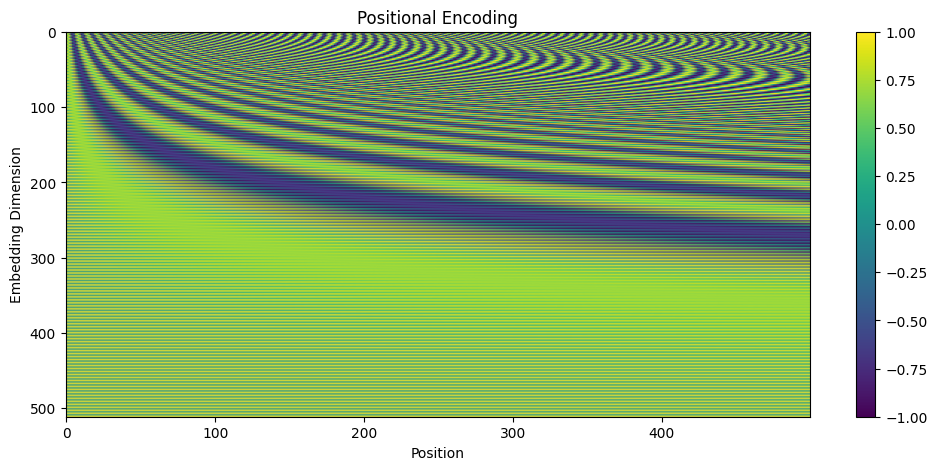

In [23]:
plt.figure(figsize=(12,5))

plt.imshow(

    pe.pe[0].numpy().T,

    aspect="auto",

    cmap="viridis"

)

plt.xlabel("Position")

plt.ylabel("Embedding Dimension")

plt.title("Positional Encoding")

plt.colorbar()

plt.show()

In [24]:
mha = nn.MultiheadAttention(

    embed_dim=512,

    num_heads=8,

    batch_first=True

)

x = torch.randn(

    4,

    20,

    512

)

output, attention = mha(

    x,

    x,

    x

)

print(output.shape)

print(attention.shape)

torch.Size([4, 20, 512])
torch.Size([4, 20, 20])


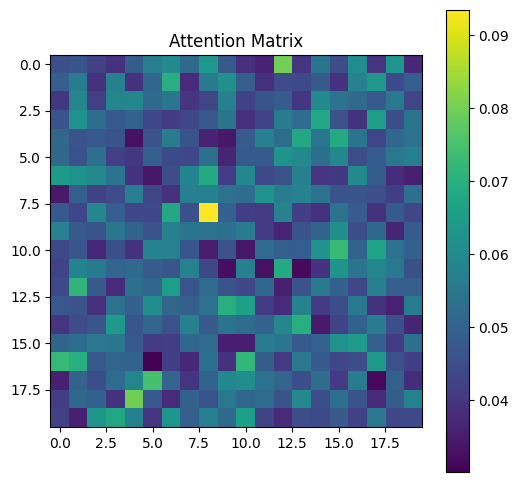

In [25]:
plt.figure(figsize=(6,6))

plt.imshow(

    attention[0].detach().numpy(),

    cmap="viridis"

)

plt.colorbar()

plt.title("Attention Matrix")

plt.show()